#### Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from pathlib import Path
from scipy.stats import norm, invgamma, multivariate_normal
import pickle
import os

from scipy import stats as scipy_stats
from scipy.stats import skewnorm, t, nct, norminvgauss
from scipy.optimize import minimize
from skewt_scipy.skewt import skewt

from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import contextlib
import io

from kama_msr import KAMA
from kama_msr import MarkovSwitchingModel
from kama_msr import KAMA_MSR
from kmrf import KMRF
from KMRF_training_config import *
from bayesian_forward_simulator import BayesianForwardSimulator
from portfolio_optimizer_inputs import PortfolioOptimizerInputs
from portfolio_optimizer import PortfolioOptimizer

## Data

#### --------------------------------------------------------------------

In [2]:
# Prepare data: etf_close_prices, commodity_close_prices, universe_close_prices
international_index_symbol_names = pd.read_csv('data/inputs/fmp_index_list.csv').set_index('symbol')['name']
international_index_symbol_names = international_index_symbol_names[~international_index_symbol_names.index.isin(['^GSPC', '^NDX'])].to_dict()
commodity_symbol_names = pd.read_csv('data/inputs/fmp_commodity_list.csv').set_index('symbol')['name'].to_dict()
etf_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # International EQUITY ETFS
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
universe_symbol_names = {
    'IVV': 'IVV - iShares Core S&P 500 ETF',
    'IJH': 'IJH - iShares Core S&P Mid-Cap ETF',
    'IWM': 'IWM - iShares Russell 2000 ETF',
    'EFA': 'EFA - iShares MSCI EAFE ETF',
    'EEM': 'EEM - iShares MSCI Emerging Markets ETF',
    'AGG': 'AGG - iShares Core U.S. Aggregate Bond ETF',
    'SPTL': 'SPTL - SPDR Portfolio Long Term Treasury ETF',
    'HYG': 'HYG - iShares iBoxx $ High Yield Corporate Bond ETF',
    'SPBO': 'SPBO - SPDR Portfolio Corporate Bond ETF',
    'IYR': 'IYR - iShares U.S. Real Estate ETF',
    'DBC': 'DBC - Invesco DB Commodity Index Tracking Fund',
    'GLD': 'GLD - SPDR Gold Shares',
}

# international_index_data = pd.read_csv('data/processed/index_data.csv', index_col=0, header=[0, 1], parse_dates=True)
commodity_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
etf_data = pd.read_csv('data/processed/all_etf_data.csv', index_col=0, header=[0, 1], parse_dates=True)
universe_data = pd.read_csv('data/processed/universe_etfs.csv', index_col=0, header=[0, 1], parse_dates=True)

commodity_data_close_cols = commodity_data.columns[commodity_data.columns.get_level_values(1) == 'close']
commodity_close_prices = commodity_data[commodity_data_close_cols].droplevel(1, axis=1).rename(columns=commodity_symbol_names)
commodity_close_prices.columns = [col.replace('/', ' ') for col in commodity_close_prices.columns]

etf_close_cols = etf_data.columns[etf_data.columns.get_level_values(1) == 'close']
etf_close_prices = etf_data[etf_close_cols].droplevel(1, axis=1).rename(columns=etf_symbol_names)

universe_close_cols = universe_data.columns[universe_data.columns.get_level_values(1) == 'close']
universe_close_prices = universe_data[universe_close_cols].droplevel(1, axis=1).rename(columns=universe_symbol_names)

In [3]:
etf_always_disclude = ['Vanguard S&P 500 ETF', 'Real Estate Select Sector SPDR', 'Communication Services Select Sector SPDR']
etf_disclude = [name for name in etf_data.columns if 'Russell 1000' in name or 'Russell 3000' in name]\
                        + ['S&P 500', 'Nasdaq Composite', 'Dow Jones Industrial Average', 'Nasdaq 100', 'Russell 2000']

etf_include = list(set(etf_close_prices.columns.tolist()) - set(etf_always_disclude) - set(etf_disclude))
etf_close_prices = etf_close_prices[etf_include]

us_treasury = ['SPDR Bloomberg 1-3 Month T-Bill ETF', 'iShares 1-3 Year Treasury Bond ETF', 'iShares 7-10 Year Treasury Bond ETF']
int_equity = ['Vanguard Total International Stock ETF', 'Vanguard FTSE Developed Markets ETF',\
                                        'Vanguard FTSE Emerging Markets ETF','Vanguard FTSE Europe ETF',\
                                        'Vanguard FTSE Pacific ETF', 'iShares China Large-Cap ETF',\
                                        'iShares MSCI Japan ETF', 'iShares MSCI India ETF']
us_equity = list(set(etf_include) - set(us_treasury) - set(int_equity))

#### --------------------------------------------------------------------

In [4]:
# Create asset_names_df
from KMRF_training_config import *
asset_names_df = pd.DataFrame({
    'universe': get_assets_by_class('universe') + ['']*7,
    'us_equity': get_assets_by_class('us_equity'),
    'commodity': get_assets_by_class('commodity') + ['']*5,
    'int_equity': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,universe,us_equity,commodity,int_equity
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


In [5]:
all_rebal_dates = etf_close_prices['SPDR S&P 500 ETF'].to_frame().dropna().loc['2018-12-31':].index[::21].map(lambda dte: dte.strftime('%Y%m%d')).to_list()
all_dates = etf_close_prices.loc[all_rebal_dates[0]:].index[1:]

## Backtest Regime-based Optimization

In [15]:
all_rebal_dates[-13:-1]

['20241003',
 '20241101',
 '20241203',
 '20250103',
 '20250205',
 '20250307',
 '20250407',
 '20250507',
 '20250606',
 '20250709',
 '20250807',
 '20250908']

In [ ]:
ASSET_CLASS = 'us_equity'
ASSET_NAMES = asset_names_df[ASSET_CLASS][4:13].tolist()
BACKTEST_START_DATE = pd.Timestamp('2024-11-01')
BACKTEST_END_DATE = pd.Timestamp('2025-10-31')
ALLOW_SHORT = True
GROSS_EXPOSURE = 1.5 # Set to valid float value if shorting is allowed

rebal_dates = [dte for dte in all_rebal_dates if pd.Timestamp(dte) <= BACKTEST_END_DATE and pd.Timestamp(dte) >= BACKTEST_START_DATE]
rebal_dates

['20241101',
 '20241203',
 '20250103',
 '20250205',
 '20250307',
 '20250407',
 '20250507',
 '20250606',
 '20250709',
 '20250807',
 '20250908',
 '20251007']

In [ ]:
port_weights = {}
port_rets = pd.Series(dtype=float, name='Portfolio Return')
for REBAL_DATE in rebal_dates:
    opt_inputs = PortfolioOptimizerInputs.quick_run(
        asset_names=ASSET_NAMES,
        asset_class=ASSET_CLASS,
        end_date=REBAL_DATE,
        n_days=21,
        n_simulations=10000,
        alpha_confidence=1.0,
        method='path_covariance',
        annualize=True,
        verbose=False,
        random_seed=1010,
        retrain_kmrf=True,
        use_boruta_selection=False,
        use_consensus_selection=False
    )

    opt = PortfolioOptimizer.from_optimizer_inputs(opt_inputs, 
                                                   allow_short=ALLOW_SHORT, gross_exposure=GROSS_EXPOSURE,
                                                   objective='max_sharpe')
    opt_weights = opt.optimize()
    port_weights[REBAL_DATE] = opt_weights

    fwd_rets = opt.raw_ohlc[opt.assets[0]].droplevel(0, axis=1)['close'].rename(opt.assets[0]).loc[opt.opt_date:].iloc[:22].to_frame().pct_change().dropna()
    for i, asset in enumerate(opt.assets[1:]):
        fwd_rets = pd.merge(fwd_rets, opt.raw_ohlc[asset].droplevel(0, axis=1)['close'].rename(asset).loc[opt.opt_date:].iloc[:22].pct_change().dropna(), left_index=True, right_index=True)
    next_rets = fwd_rets.multiply(opt.optimal_weights).sum(axis=1)

    port_rets = pd.concat([port_rets, next_rets], axis=0)

KMRF model initialized
  Asset: Energy Select Sector SPDR
  Asset class: us_equity
  Classification type: original
  Training end date: 20241101
  Test end date: All available data
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20241101
  Validation/Test split: Will be calculated after loading data
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=False, Consensus=False

DISTRIBUTION PARAMETER VALIDATION
 regime distribution  valid       loc    scale        df        a         b  n_obs
      0 norminvgauss   True  0.003501 0.023641       NaN 2.790382 -0.350044   3882
      1    student_t   True  0.000360 0.013877 15.222629      NaN       NaN   2212
      2    student_t   True -0.014260 0.036211 30.000000      NaN       NaN     48

ValueError: No simulations available. Run simulate_all_assets() first.

In [10]:
port_rets = port_rets.rename('Portfolio Return')

In [12]:
port_rets_vs_spy = pd.merge(port_rets, 
    etf_close_prices['SPDR S&P 500 ETF'].loc[rebal_dates[0]:].pct_change().rename('SPY Return'), 
    left_index=True, right_index=True, how='left')

port_rets_vs_spy

,Portfolio Return,SPY Return
2024-11-04,-0.000711,-0.002154
2024-11-05,0.012004,0.012092
2024-11-06,0.023877,0.024866
2024-11-07,0.004506,0.007732
2024-11-08,0.007872,0.004332
...,...,...
2025-10-01,0.007932,0.003407
2025-10-02,-0.001097,0.001152
2025-10-03,0.002249,-0.000015
2025-10-06,0.003067,0.003586


<Axes: >

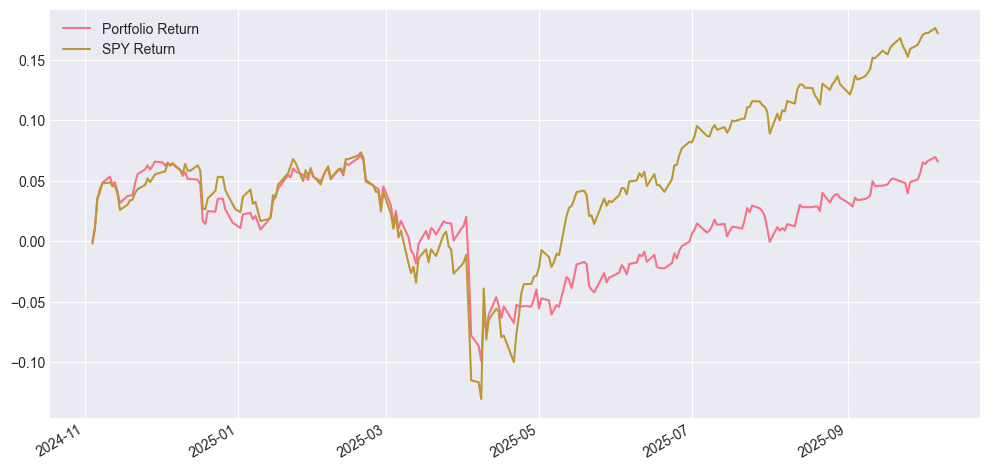

In [13]:
port_rets_vs_spy.add(1).cumprod().sub(1).plot(figsize=(12, 6))